In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='bmi', ylabel='charges'>

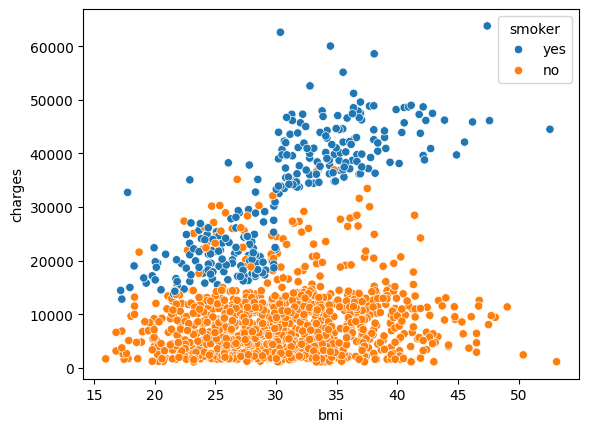

In [3]:
sns.scatterplot(x=data["bmi"],y=data["charges"],hue=data["smoker"])

In [4]:
# Variable Partition :
X = data.drop(columns=["charges"])
Y = data["charges"]

In [5]:
# Encoding :
X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [6]:
X

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.90
1,18,0,33.770,1,0,0,1,0,0,0.00
2,28,0,33.000,3,0,0,1,0,0,0.00
3,33,0,22.705,0,0,1,0,0,0,0.00
4,32,0,28.880,0,0,1,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0,0,0.00
1334,18,1,31.920,0,0,0,0,0,0,0.00
1335,18,1,36.850,0,0,0,1,0,0,0.00
1336,21,1,25.800,0,0,0,0,1,0,0.00


In [7]:
# Train - Test - Split : 

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
# Model Training Phase :
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, Y_train)

,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.","[0.001, 0.1, ...]"
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [15]:
# Making the value prediction :

print("best alpha: ", lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)

best alpha:  0.001


In [17]:
y_pred

array([11244.90059978,  7419.09546268, 33108.56314007, 10825.70490225,
       28165.85343431,  6492.31635767,  2795.32365354, 14417.83354245,
        5686.99898738, 11674.71818244, 20657.63411334,  9146.42228702,
        5695.47634768, 51922.22671926, 52110.29374917, 46640.13982805,
       11685.29658629, 43258.62998667, 10134.76616091, 27544.19263391,
        5590.70961111,  9112.26802402,  1829.44144206,  4568.32135944,
       12451.66467979, 12838.43441863, 13233.1683341 ,  6449.57391511,
       11799.9295961 ,  1825.10892897,  9707.98336691, 12978.53929819,
        3236.118998  ,  7025.38251479,  4125.34903234, 10091.32515432,
        3262.60158493,  9119.59900771, 26284.76520845, 37686.42549368,
        4634.26679081,  3702.06925208, 12658.70586842, 12849.09340889,
        6810.6449285 , 12752.77601579,  4474.36939417,  5198.07859716,
       41615.56500411,  6338.52575124, 14310.54334662,  2272.59365192,
        9166.72907954,  2711.78458203, 11905.93655599, 12175.66877205,
      

In [18]:
# Pair for the comparisons :

pair = [(float(x),y) for x,y in zip(y_pred,Y_test)]
print(pair)

[(11244.900599775812, 9095.06825), (7419.095462683352, 5272.1758), (33108.56314006999, 29330.98315), (10825.704902248643, 9301.89355), (28165.85343430873, 33750.2918), (6492.316357665728, 4536.259), (2795.3236535363885, 2117.33885), (14417.83354244978, 14210.53595), (5686.998987382676, 3732.6251), (11674.718182439636, 10264.4421), (20657.634113344226, 18259.216), (9146.422287023415, 7256.7231), (5695.476347678898, 3947.4131), (51922.22671925753, 46151.1245), (52110.293749173725, 48673.5588), (46640.13982805462, 44202.6536), (11685.296586288745, 9800.8882), (43258.62998667486, 42969.8527), (10134.766160914243, 8233.0975), (27544.19263391164, 21774.32215), (5590.709611110315, 5080.096), (9112.268024019668, 7441.501), (1829.4414420557914, 1256.299), (4568.32135943513, 2755.02095), (12451.66467978568, 11085.5868), (12838.434418626546, 10923.9332), (13233.168334097803, 12644.589), (6449.573915111856, 18804.7524), (11799.929596100035, 9715.841), (1825.10892896541, 1131.5066), (9707.983366906

In [19]:
# Evaluation Metrics :

In [20]:
# Mean Squared Value :

mse = mean_squared_error(Y_test, y_pred)
print(mse)

20922599.871035974


In [21]:
# 1] R Squared :

from sklearn.metrics import r2_score
r_square = r2_score(Y_test, y_pred)
# Linear Regression R square value : 0.7811302113434095 
print(f"R square value : {r_square} ")

R square value : 0.8652317499151698 


In [22]:
# 2 Adjusted R Squared :

# No. of rows :
n = X_test.shape[0]
print(X_test.shape[0])

# No. of cols :
p = X_test.shape[1]
print(X_test.shape[1])


# Linear Regression: 
# Adjusted R Square Value :0.7769533069797342

r_adjusted = 1-(((1-r_square)*(n-1))/(n-p-1))

print(f"Adjusted R Square Value :{r_adjusted}")

268
10
Adjusted R Square Value :0.8599878491336589


20922599.871035974
20921803.69843139
20914832.635089148
20908106.779954527
20890881.000633504
20872844.794796687
20877828.53237883
20937537.13393977
21046489.293890774
21196929.869608898
22423172.68602322
Best alpha = 


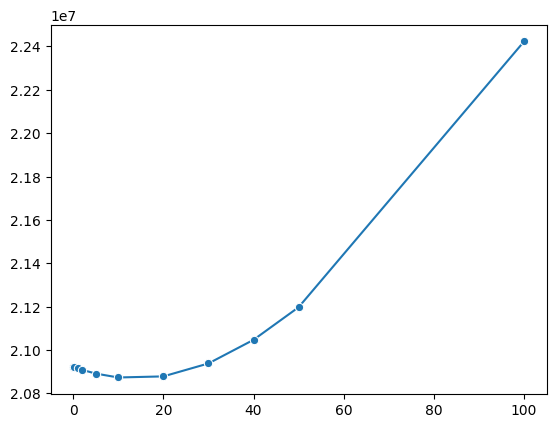

In [23]:
# Finding the best alpha :


alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []


for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, Y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(Y_test,y_pred)
    print(mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")
print(f"Best alpha = ")